<a href="https://colab.research.google.com/github/AmanuelDaget/AmanuelDaget/blob/main/Brain-Tumor-Detection-on-MRI-Using-Transfer-Learning-with-VGG16/VGG_16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Brain Tumor classification using VGG-16 **

In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms, datasets
from PIL import Image
from matplotlib import pyplot as plt

# **DATA PREPROCESSING**

**Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_DIR = '/content/drive/MyDrive/Colab Notebooks/Computer Vision and Image Processing/brain-tumor-detection-dataset'

**Define Parameters**

In [5]:
BATCH_SIZE = 16
TEST_SPLIT = 0.2
EPOCHS = 5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

**Transforms**

In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

**Dataset and Train/Test Split**

In [7]:
# Load using ImageFolder (expects subfolders per class)
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

num_test = int(len(full_dataset) * TEST_SPLIT)
num_train = len(full_dataset) - num_test
train_dataset, test_dataset = random_split(full_dataset, [num_train, num_test], generator=torch.Generator().manual_seed(42))

# Assign test transforms to test_dataset (ensures no augmentation on test set)
test_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

**VGG16 Model Setup**

In [8]:
vgg16 = models.vgg16(pretrained=True)

# Freeze all layers except final classifier
for param in vgg16.parameters():
    param.requires_grad = False

num_features = vgg16.classifier[6].in_features
vgg16.classifier[6] = nn.Linear(num_features, 2)
vgg16 = vgg16.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(vgg16.classifier[6].parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 123MB/s] 


**Training Loop**

In [29]:
# Lists to store metrics for visualization
train_losses, test_losses = [], []
train_accuracies, test_accuracies = [], []
for epoch in range(EPOCHS):
    # --- Training ---
    vgg16.train()
    running_loss, running_correct = 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = vgg16(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_correct / len(train_dataset)
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)



**Test (Evaluation) Loop**

In [30]:
for epoch in range(EPOCHS):
 # --- Testing ---
  vgg16.eval()
  test_loss, test_correct = 0.0, 0
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(DEVICE), labels.to(DEVICE)
          outputs = vgg16(images)
          loss = criterion(outputs, labels)
          test_loss += loss.item() * images.size(0)
          _, preds = torch.max(outputs, 1)
          test_correct += (preds == labels).sum().item()
  epoch_test_loss = test_loss / len(test_dataset)
  epoch_test_acc = test_correct / len(test_dataset)
  test_losses.append(epoch_test_loss)
  test_accuracies.append(epoch_test_acc)

  print(f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.2f} | "
        f"Test Loss: {epoch_test_loss:.4f} | Test Acc: {epoch_test_acc:.2f}")

Epoch 1/5 | Train Loss: 0.4447 | Train Acc: 0.80 | Test Loss: 0.4484 | Test Acc: 0.78
Epoch 2/5 | Train Loss: 0.4447 | Train Acc: 0.80 | Test Loss: 0.4484 | Test Acc: 0.78
Epoch 3/5 | Train Loss: 0.4447 | Train Acc: 0.80 | Test Loss: 0.4484 | Test Acc: 0.78
Epoch 4/5 | Train Loss: 0.4447 | Train Acc: 0.80 | Test Loss: 0.4484 | Test Acc: 0.78
Epoch 5/5 | Train Loss: 0.4447 | Train Acc: 0.80 | Test Loss: 0.4484 | Test Acc: 0.78


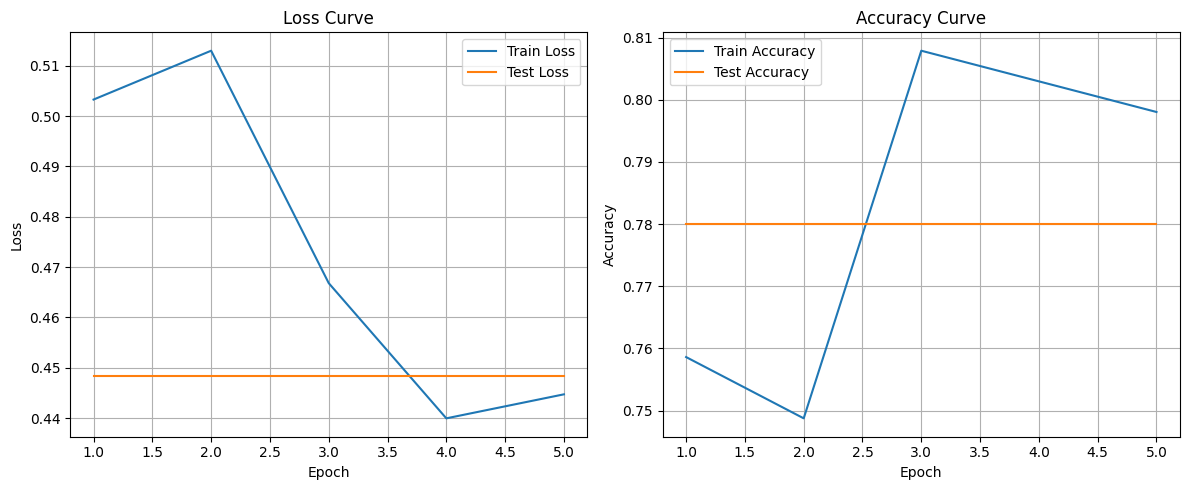

In [31]:
epochs_range = range(1, EPOCHS+1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Predict on a Single Image**

In [23]:
def predict_image(img_path, model, class_names):
    model.eval()
    img = Image.open(img_path).convert("RGB")
    img = test_transforms(img)
    img = img.unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        output = model(img)
        _, pred = torch.max(output, 1)
    print(f"Prediction: {class_names[pred.item()]}")
    return class_names[pred.item()]

# Example usage:
class_names = full_dataset.classes
predict_image(os.path.join(DATA_DIR, 'yes', 'Y1.jpg'), vgg16, class_names)

Prediction: yes


'yes'

**Confusion Matrix**

In [32]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

vgg16.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = vgg16(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))

print("Confusion Matrix:")
print(confusion_matrix(all_labels, all_preds))

Classification Report:
              precision    recall  f1-score   support

          no       0.86      0.38      0.52        16
         yes       0.77      0.97      0.86        34

    accuracy                           0.78        50
   macro avg       0.81      0.67      0.69        50
weighted avg       0.80      0.78      0.75        50

Confusion Matrix:
[[ 6 10]
 [ 1 33]]


In [36]:
# Collect all test predictions
all_preds = []
all_labels = []

vgg16.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = vgg16(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

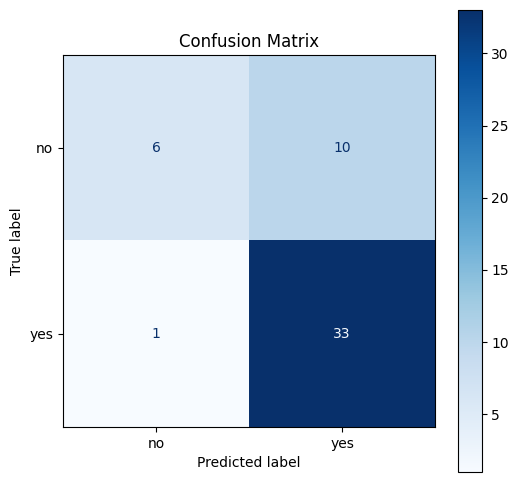

In [35]:
class_names = full_dataset.classes  # e.g., ['no', 'yes']

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=True, values_format='d')
plt.title("Confusion Matrix")
plt.show()